<a href="https://colab.research.google.com/github/lohiapragati7/random/blob/main/Superstore_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [2]:
data = pd.read_csv('Superstore_Data.csv')

In [4]:
data.head()

,Order Date,Sales,Profit
0,17-10-2013,5175.171,919.971
1,07-11-2011,1822.080,564.840
2,14-04-2012,5244.840,996.480
3,06-06-2013,3701.520,1036.080
4,25-02-2012,1878.720,582.360


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  5699 non-null   object 
 1   Sales       5699 non-null   float64
 2   Profit      5699 non-null   float64
dtypes: float64(2), object(1)
memory usage: 133.7+ KB


In [8]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data.dtypes

,0
Order Date,datetime64[ns]
Sales,float64
Profit,float64


In [9]:
data.sort_values('Order Date',ascending=True,inplace=True)

In [10]:
data.head()

,Order Date,Sales,Profit
5073,2011-01-01,55.242,15.342
3056,2011-01-01,120.366,36.036
4083,2011-01-01,113.670,37.770
424,2011-01-03,912.456,-319.464
5517,2011-01-03,6.006,0.546


In [11]:
data.set_index('Order Date',inplace=True)
data.head()

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [12]:
data.iloc[1]

,2011-01-01
Sales,120.366
Profit,36.036


In [15]:
data.loc['2011-01-01']

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770


In [17]:
data.loc['2011-01-01':'2012-09-12'].sum()

,0
Sales,535812.4164
Profit,67210.8264


In [18]:
data.shape

(5699, 2)

In [20]:
data = data.groupby(pd.Grouper(freq='M')).sum()

In [21]:
data

,Sales,Profit
Order Date,,
2011-01-31,15711.7125,991.2825
2011-02-28,12910.8588,1338.8688
2011-03-31,19472.5632,3747.1632
2011-04-30,15440.3046,3846.4746
2011-05-31,24348.9723,3639.9423
2011-06-30,27260.0196,4328.2596
2011-07-31,15842.8317,1258.9617
2011-08-31,22012.2366,775.8066
2011-09-30,34613.1849,5181.4449


In [22]:
data.shape

(48, 2)

In [32]:
df_sales = data.copy()

In [33]:
df_sales.shape

(48, 2)

In [34]:
df_sales.drop(columns='Profit',inplace=True)

In [35]:
df_sales.head()

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


<Axes: xlabel='Order Date'>

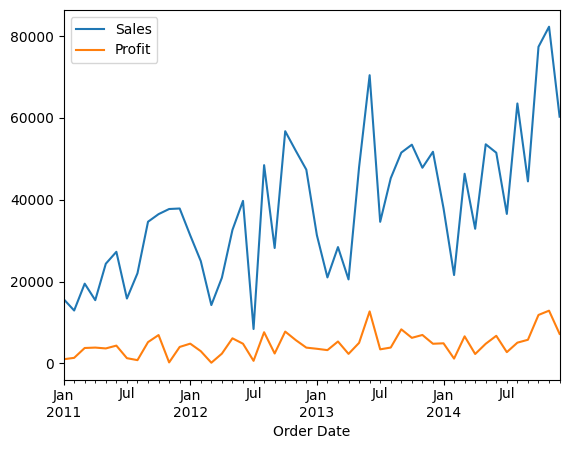

In [27]:
data.plot()

Stationarity Test

In [28]:
from statsmodels.tsa.stattools import adfuller

In [36]:
result = adfuller(df_sales['Sales'])

The Null Hypothesis for adfuller is "The Time Series Data is not stationary.

If p-value>0.05, then data is non-stationary.

In [31]:
result[1]

np.float64(0.1987628396941693)

In [37]:
data.shape

(48, 2)

In [38]:
df_s_train = df_sales[0:42]
df_s_test = df_sales[42:]

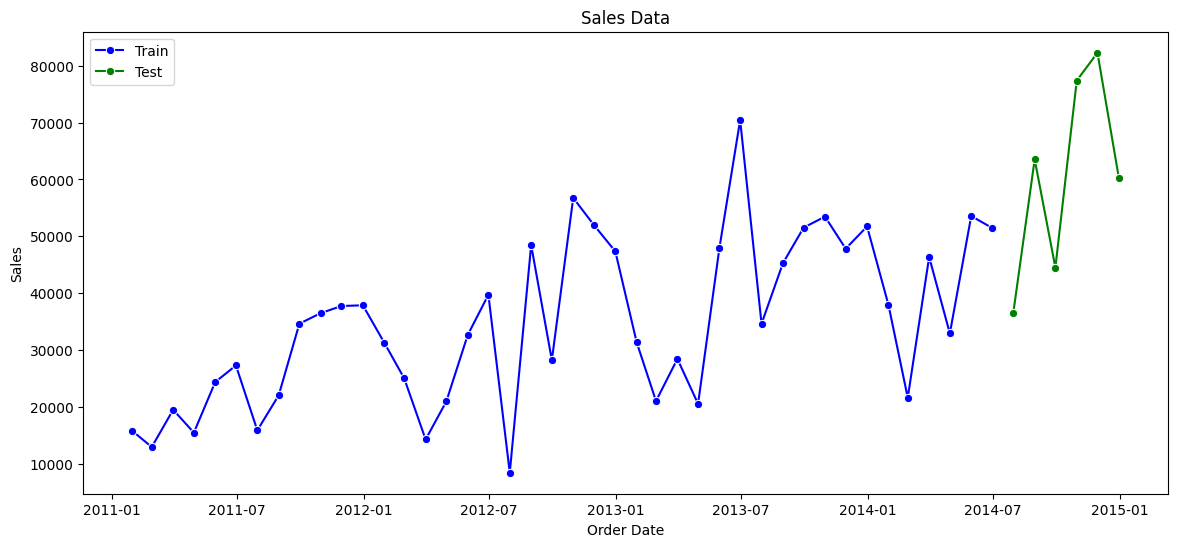

In [39]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_s_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_s_test, x = 'Order Date', y = 'Sales', marker = 'o', color = 'green', label = 'Test')
plt.title('Sales Data');

Time-series transformations

In [40]:
from scipy.stats import boxcox

In [41]:
df_s_train.head()

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


In [42]:
box_sales = pd.Series(boxcox(df_s_train['Sales'],lmbda=0),index=df_s_train.index)

In [44]:
box_sales.head()

,0
Order Date,
2011-01-31,9.662162
2011-02-28,9.465824
2011-03-31,9.876762
2011-04-30,9.644737
2011-05-31,10.100245


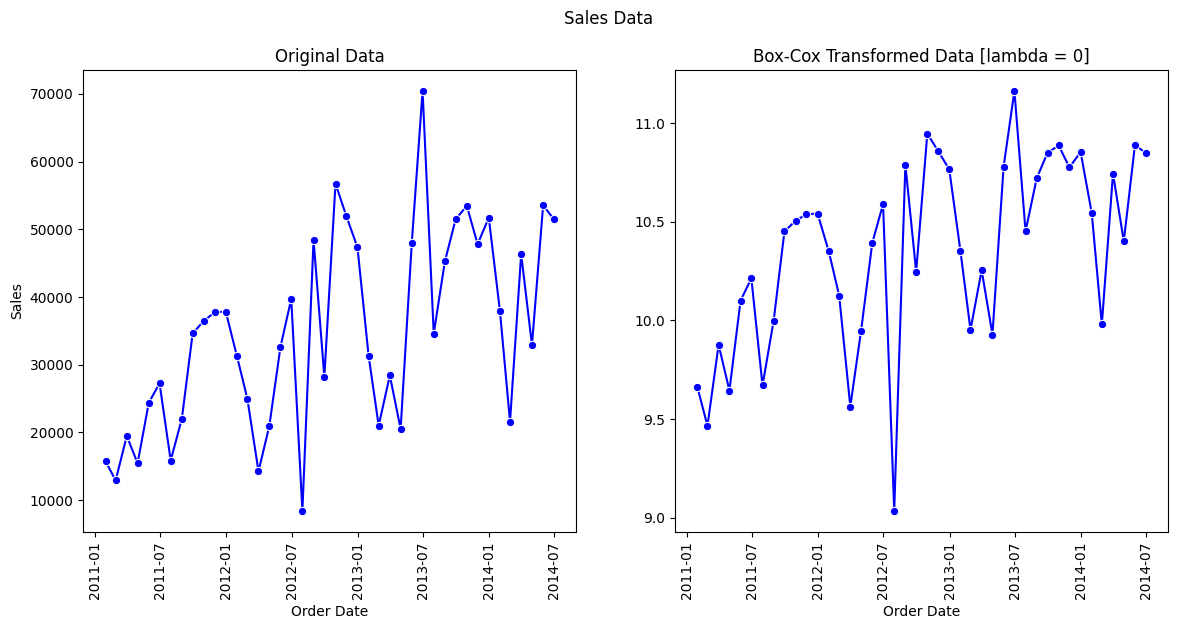

In [45]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_s_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
sns.lineplot(x = box_sales.index, y = box_sales.values, marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Box-Cox Transformed Data [lambda = 0]')

plt.suptitle('Sales Data');

In [46]:
diff_sales = df_s_train.diff()

In [48]:
diff_sales.head()

,Sales
Order Date,
2011-01-31,NaN
2011-02-28,-2800.8537
2011-03-31,6561.7044
2011-04-30,-4032.2586
2011-05-31,8908.6677


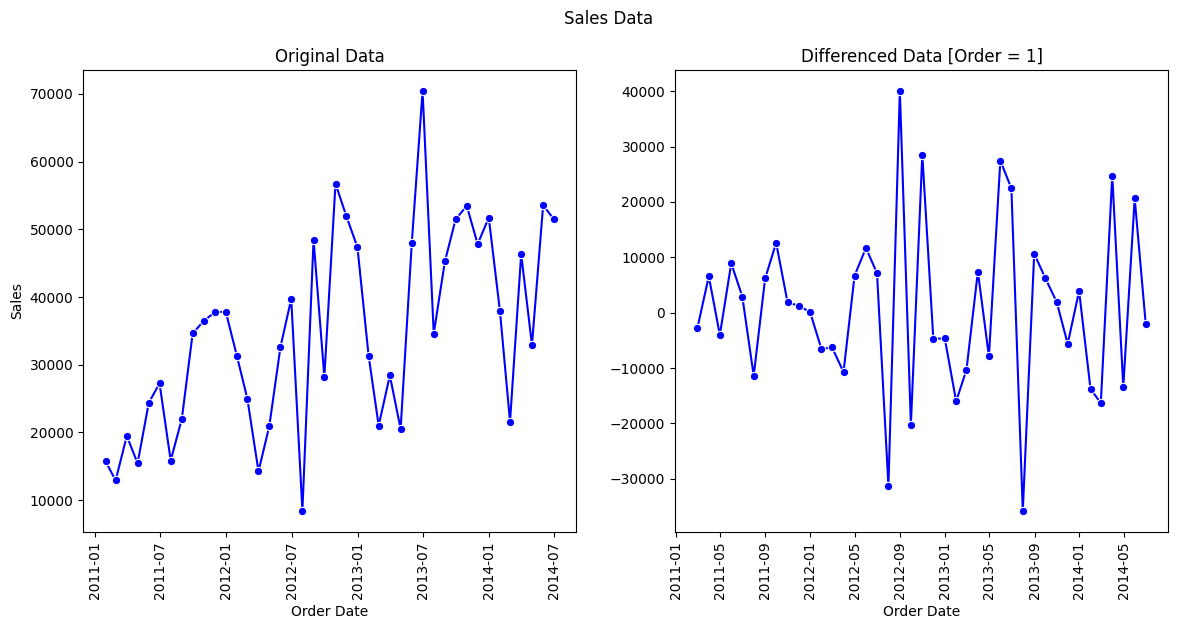

In [51]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_s_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
sns.lineplot(x = diff_sales.index, y = diff_sales['Sales'].values, marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Differenced Data [Order = 1]')

plt.suptitle('Sales Data');

In [52]:
box_diff_sales = box_sales.diff()

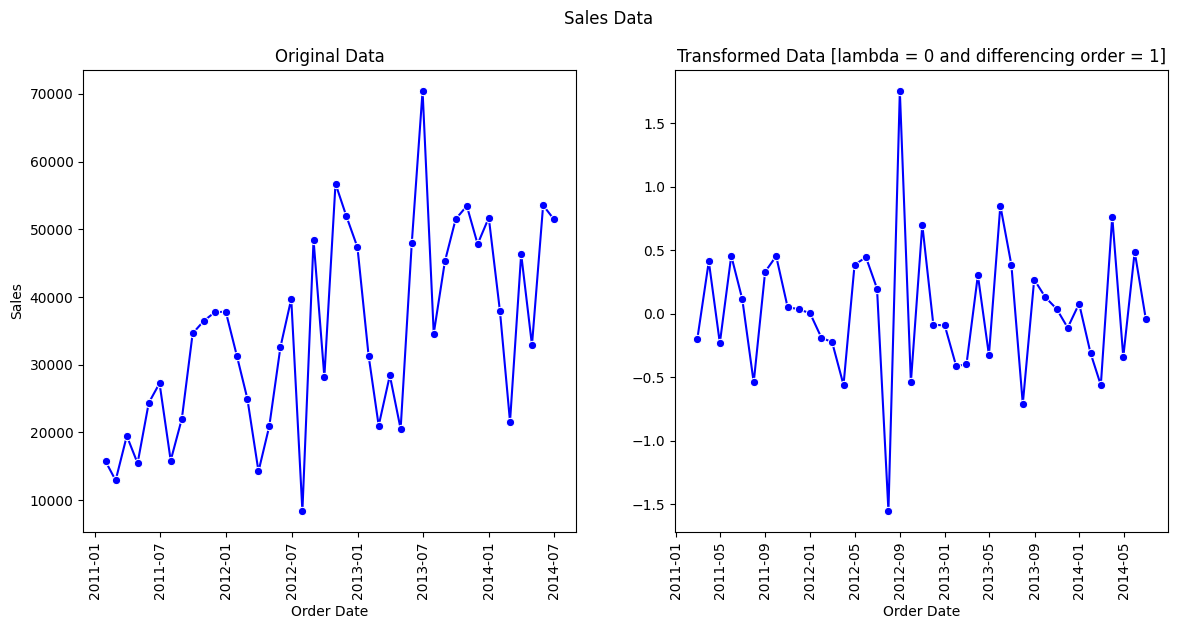

In [54]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_s_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
sns.lineplot(x = box_diff_sales.index, y = box_diff_sales.values, marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Transformed Data [lambda = 0 and differencing order = 1]')

plt.suptitle('Sales Data');

In [57]:
result_after_transformations = adfuller(box_diff_sales[1:])
result_after_transformations[1]

np.float64(7.4522117377521425e-06)

Auto-Correlation plots

In [58]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

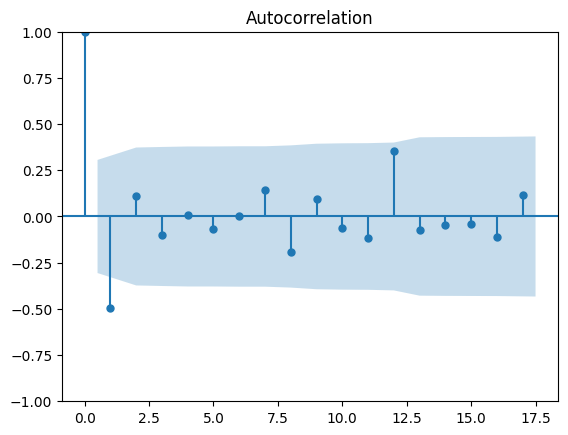

In [61]:
plot_acf(box_diff_sales[1:]);

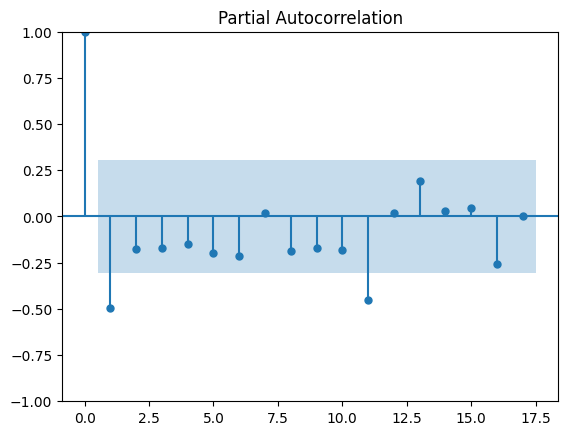

In [62]:
plot_pacf(box_diff_sales[1:]);

In [63]:
import statsmodels.api as sm

order_aic_bic =[]

for p in range(3):
  for q in range(3):
    try:
      model = sm.tsa.statespace.SARIMAX(df_sales['Sales'],order=(p, 0, q))
      results = model.fit()
      order_aic_bic.append((p, q, results.aic, results.bic))
    except:
      print(p, q, None, None)

order_df = pd.DataFrame(order_aic_bic, columns=['p', 'q','aic','bic'])

# Sort by AIC
print("Sorted by AIC: ")
print("\n")
print(order_df.sort_values('aic').reset_index(drop=True))

# Sort by BIC
print("\n")
print("Sorted by BIC: ")
print("\n")

print(order_df.sort_values('bic').reset_index(drop=True))

Sorted by AIC: 


   p  q          aic          bic
0  1  1  1061.306842  1066.920445
1  2  1  1062.862845  1070.347649
2  1  2  1063.570764  1071.055568
3  2  0  1063.671028  1069.284631
4  2  2  1065.328869  1074.684874
5  1  0  1071.820241  1075.562643
6  0  2  1133.919119  1139.532722
7  0  1  1136.980739  1140.723141
8  0  0  1159.086086  1160.957287


Sorted by BIC: 


   p  q          aic          bic
0  1  1  1061.306842  1066.920445
1  2  0  1063.671028  1069.284631
2  2  1  1062.862845  1070.347649
3  1  2  1063.570764  1071.055568
4  2  2  1065.328869  1074.684874
5  1  0  1071.820241  1075.562643
6  0  2  1133.919119  1139.532722
7  0  1  1136.980739  1140.723141
8  0  0  1159.086086  1160.957287


Model Evaluation

In [64]:
from statsmodels.tsa.arima.model import ARIMA

In [65]:
ar_model = ARIMA(box_diff_sales,order=(1,0,0))
ar_model = ar_model.fit()

In [69]:
train_len=42
ar_model_preds = ar_model.predict(start=train_len,end=len(df_sales)-1)
ar_model_preds

,predicted_mean
2014-07-31,0.065469
2014-08-31,0.014786
2014-09-30,0.039315
2014-10-31,0.027443
2014-11-30,0.033189
2014-12-31,0.030408


In [70]:
df_s_test

,Sales
Order Date,
2014-07-31,36524.3028
2014-08-31,63521.7729
2014-09-30,44477.2662
2014-10-31,77379.8286
2014-11-30,82286.3583
2014-12-31,60292.1310


In [72]:
df_boxcox_diff_preds=pd.concat([box_diff_sales,ar_model_preds])

In [73]:
df_boxcox_preds=df_boxcox_diff_preds.cumsum()
df_boxcox_preds=df_boxcox_preds.add(box_sales[0])

In [75]:
sales_preds=np.exp(df_boxcox_preds)
sales_preds.head()

,0
2011-01-31,NaN
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


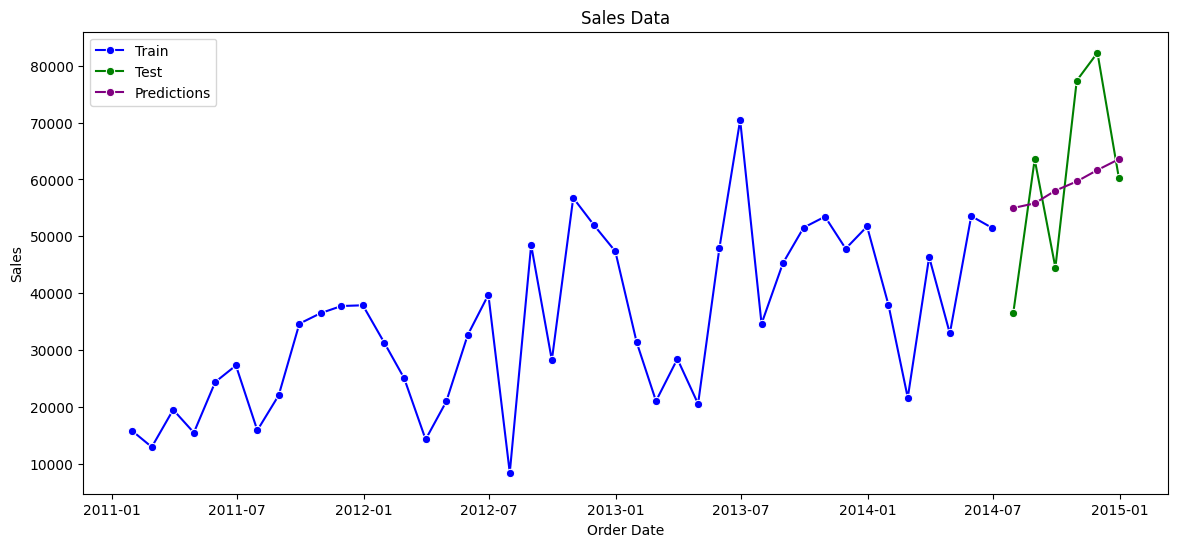

In [77]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_s_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_s_test, x = 'Order Date', y = 'Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = sales_preds.index[train_len:], y = sales_preds.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data');

In [78]:
from sklearn.metrics import mean_squared_error

In [80]:
rmse = np.sqrt(mean_squared_error(y_true = df_s_test['Sales'], y_pred = sales_preds.values[train_len:]))

rmse = np.round(rmse, 2)

performance_df = pd.DataFrame(index = [0],data = {'Model': 'AR', 'RMSE': rmse})

performance_df.set_index('Model', inplace = True)

performance_df

,RMSE
Model,
AR,14915.16


In [82]:
arima_model = ARIMA(box_sales, order = (1, 1, 1))
arima_model = arima_model.fit()

In [83]:
train_len = 42
arima_model_preds = arima_model.predict(start = train_len, end = len(data) - 1)

In [85]:
df_boxcox_preds = pd.concat([box_sales, arima_model_preds])

In [86]:
df_preds = np.exp(df_boxcox_preds)

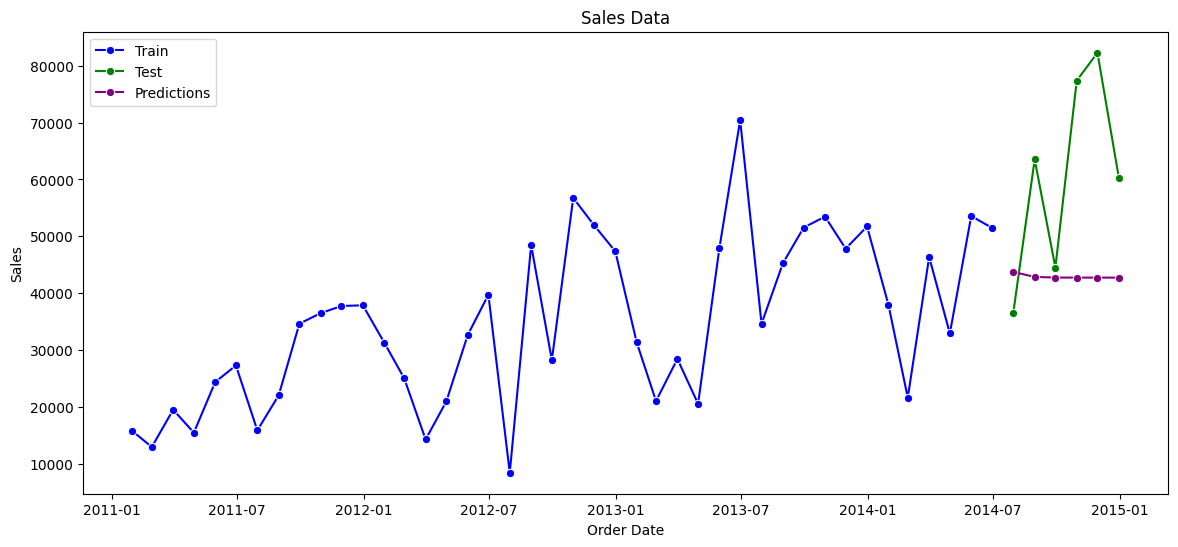

In [88]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_s_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_s_test, x = 'Order Date', y = 'Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds.index[train_len:], y = df_preds.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data');

In [89]:
rmse = np.sqrt(mean_squared_error(y_true = df_s_test['Sales'], y_pred = df_preds.values[train_len:]))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'ARIMA', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df

,RMSE
Model,
AR,14915.16
ARIMA,24353.72


In [91]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [92]:
sarima_model=SARIMAX(box_sales,oredr=(1,1,1),seasonal_order=(1,1,1,12))
sarima_model=sarima_model.fit()

In [93]:
train_len = 42
sarima_model_preds = sarima_model.predict(start = train_len, end = len(data)-1)

In [95]:
df_boxcox_preds = pd.concat([box_sales,sarima_model_preds])

In [96]:
df_preds = np.exp(df_boxcox_preds)

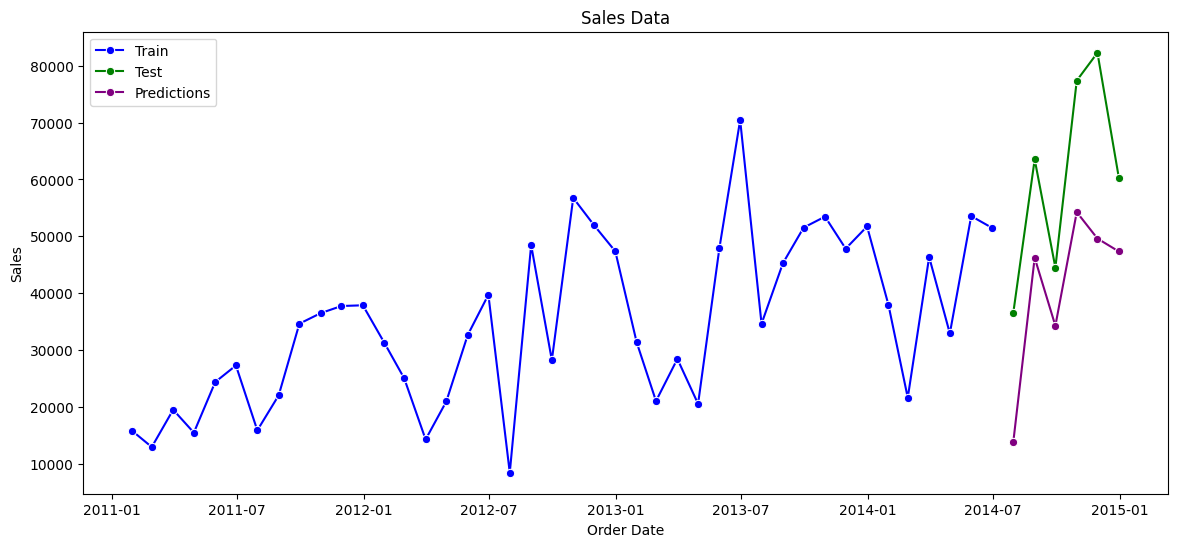

In [97]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_s_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_s_test, x = 'Order Date', y = 'Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds.index[train_len:], y = df_preds.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data');

In [99]:
rmse = np.sqrt(mean_squared_error(y_true = df_s_test['Sales'], y_pred = df_preds.values[train_len:]))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df

,RMSE
Model,
AR,14915.16
ARIMA,24353.72
SARIMA,21186.61
